# Setup

Load libraries and import dataset through `kagglehub`

In [ ]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score

import statsmodels.api as sm

In [2]:
!pip install kagglehub
import kagglehub

# Download latest version of the dataset
path = kagglehub.dataset_download("lakshitasharma0404/ibm-hr-employee-attrition-data")

100%|██████████| 67.1k/67.1k [00:00<00:00, 48.6MB/s]

Extracting files...


In [3]:
# Load the CSV file
file_path = os.path.join(path, "IBM HR Employee Attrition Data.csv")
df = pd.read_csv(file_path)

print(f"{"Original Dataset":-^60}")
df.info()


----------------------Original Dataset----------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement   

# Data Cleaning

Before proceeding with the analysis, data should be checked for missing, duplicate, or erroneous values that should be fixed.

In [ ]:
# Keep only relevant columns for analysis
# Demographic values, such as Age, are dropped because it's unethical to hire based on demographic profile
# Redundant values, such as DailyRate, are dropped.
# Values that are only applicable to employees who are already employed, such as YearsWithCurrManager, are dropped
# because the target population in applying the analytic results are potential employees who are in the recruitment pool
# StockOptionLevel, Department, Job Role, Job Level, and Monthly Salary are also excluded because they are not based on
# the employee candidates, but the employers or both
df_analysis = df[['Attrition', 'DistanceFromHome', 'Education', 'EducationField', 'NumCompaniesWorked',
                  'PercentSalaryHike', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance']].copy()

In [ ]:
# Show the analysis dataset information
print(f"\n{"Dataset for Analysis":-^60}")
df_analysis.info()


--------------------Dataset for Analysis--------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Attrition              1470 non-null   object
 1   DistanceFromHome       1470 non-null   int64 
 2   Education              1470 non-null   int64 
 3   EducationField         1470 non-null   object
 4   NumCompaniesWorked     1470 non-null   int64 
 5   PercentSalaryHike      1470 non-null   int64 
 6   TotalWorkingYears      1470 non-null   int64 
 7   TrainingTimesLastYear  1470 non-null   int64 
 8   WorkLifeBalance        1470 non-null   int64 
dtypes: int64(7), object(2)
memory usage: 103.5+ KB


In [ ]:
# Create a shallow copy
df_analysis_copy = df_analysis.copy()

print("Dataset Shape: ",df_analysis_copy.shape, "\nNumber of Columns:", len(df_analysis_copy.columns))
df_analysis_copy.head(10)

Dataset Shape:  (1470, 9) 
Number of Columns: 9


,Attrition,DistanceFromHome,Education,EducationField,NumCompaniesWorked,PercentSalaryHike,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance
0,Yes,1,2,Life Sciences,8,11,8,0,1
1,No,8,1,Life Sciences,1,23,10,3,3
2,Yes,2,2,Other,6,15,7,3,3
3,No,3,4,Life Sciences,1,11,8,3,3
4,No,2,1,Medical,9,12,6,3,3
5,No,2,2,Life Sciences,0,13,8,2,2
6,No,3,3,Medical,4,20,12,3,2
7,No,24,1,Life Sciences,1,22,1,2,3
8,No,23,3,Life Sciences,0,21,10,2,3
9,No,27,3,Medical,6,13,17,3,2


In [7]:
# Check missing data
df_analysis_copy.isna().sum()

,0
Attrition,0
DistanceFromHome,0
Education,0
EducationField,0
NumCompaniesWorked,0
PercentSalaryHike,0
TotalWorkingYears,0
TrainingTimesLastYear,0
WorkLifeBalance,0


In [8]:
# Check number of unique values
df_analysis_copy.nunique()

,0
Attrition,2
DistanceFromHome,29
Education,5
EducationField,6
NumCompaniesWorked,10
PercentSalaryHike,15
TotalWorkingYears,40
TrainingTimesLastYear,7
WorkLifeBalance,4


In [9]:
# Check number of duplicates
print("Number of Duplicate Values:", df_analysis_copy.duplicated().sum())

Number of Duplicate Values: 0


In [10]:
# Check categorical values
for col in df_analysis_copy.select_dtypes(include=["object"]).columns:
    print(df_analysis_copy[col].value_counts(dropna=False))
    print("-" * 40)

Attrition
No     1233
Yes     237
Name: count, dtype: int64
----------------------------------------
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64
----------------------------------------


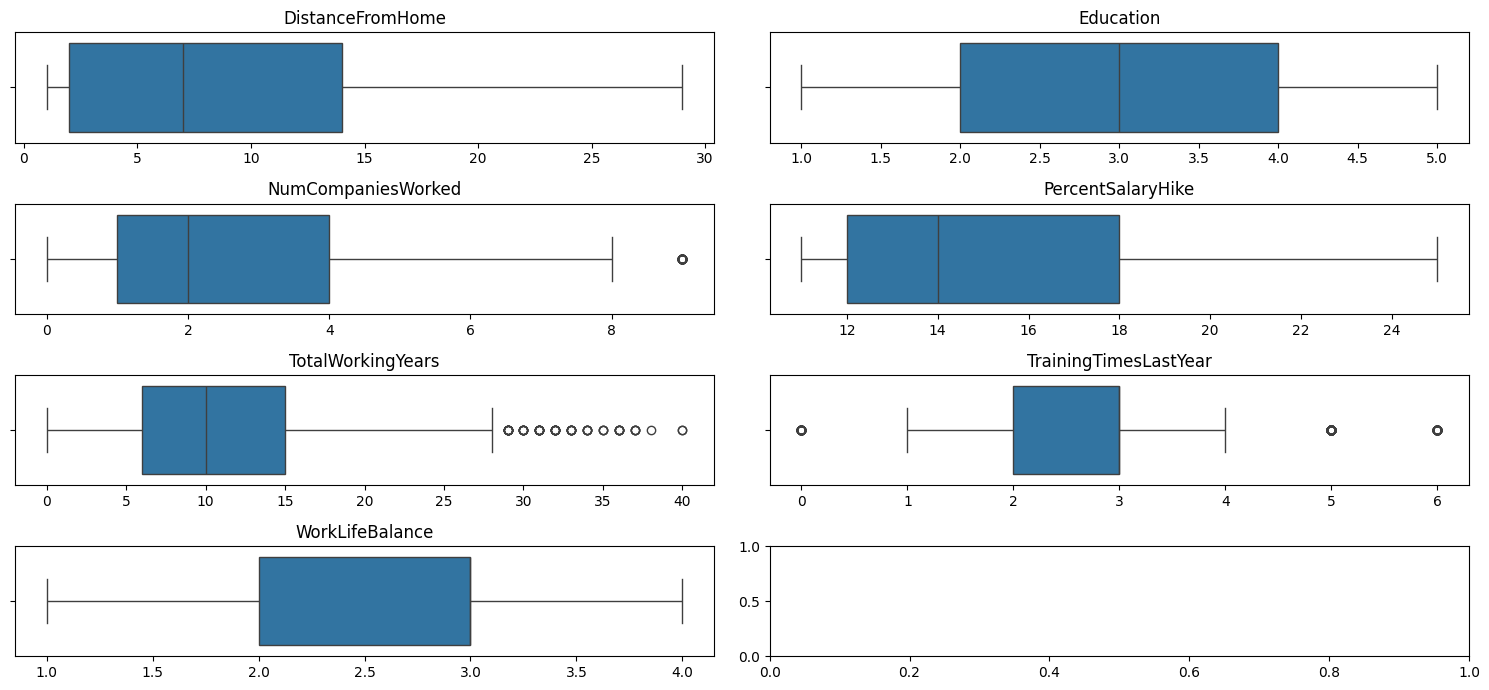

In [11]:
# Visualize outliers for each numerical variables
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 7))
axes = axes.flatten()
for i, col in enumerate(df_analysis_copy.select_dtypes(include="int64").columns):
    sns.boxplot(x=df_analysis_copy[col], ax=axes[i])
    axes[i].set_xlabel("")
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [12]:
# Check columns with outliers
for col in df_analysis_copy[["TrainingTimesLastYear", "NumCompaniesWorked", "TotalWorkingYears"]]:
    print(col)
    q1 = df_analysis_copy[col].quantile(0.25)
    q3 = df_analysis_copy[col].quantile(0.75)
    iqr = q3-q1
    ll = q1-(1.5*iqr)
    ul = q3+(1.5*iqr)

    # Check the number of outliers for each column
    n_ol = len(df_analysis_copy[(df_analysis_copy[col].map(lambda i: i < ll or i > ul))])
    print("Number of Outliers:", n_ol)
    print("Percentage of Outliers:", f"{n_ol/len(df_analysis_copy[col])*100:.2f}%", "\n")

TrainingTimesLastYear
Number of Outliers: 238
Percentage of Outliers: 16.19% 

NumCompaniesWorked
Number of Outliers: 52
Percentage of Outliers: 3.54% 

TotalWorkingYears
Number of Outliers: 63
Percentage of Outliers: 4.29% 



Based on the boxplots above, only three variables showed notable outliers based on the boxplots. However, they will be kept because there is no evidence that suggests data-entry error as these values are plausible observations. For example, there will be a number of people who will have more than 27 years of work experience and the analysis should be able to account for them.

# Exploratory Analysis

In [13]:
# Summary of numerical data
df_analysis.describe()

,DistanceFromHome,Education,NumCompaniesWorked,PercentSalaryHike,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,9.192517,2.912925,2.693197,15.209524,11.279592,2.799320,2.761224
std,8.106864,1.024165,2.498009,3.659938,7.780782,1.289271,0.706476
min,1.000000,1.000000,0.000000,11.000000,0.000000,0.000000,1.000000
25%,2.000000,2.000000,1.000000,12.000000,6.000000,2.000000,2.000000
50%,7.000000,3.000000,2.000000,14.000000,10.000000,3.000000,3.000000
75%,14.000000,4.000000,4.000000,18.000000,15.000000,3.000000,3.000000
max,29.000000,5.000000,9.000000,25.000000,40.000000,6.000000,4.000000


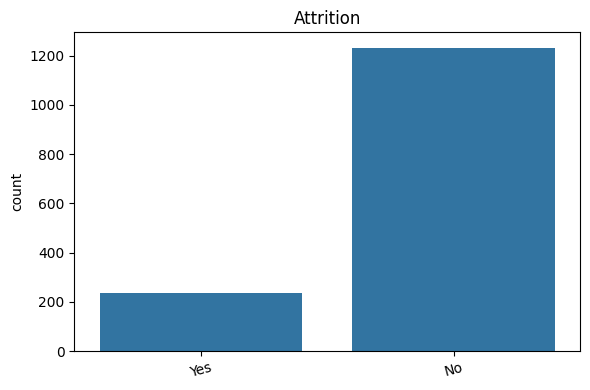

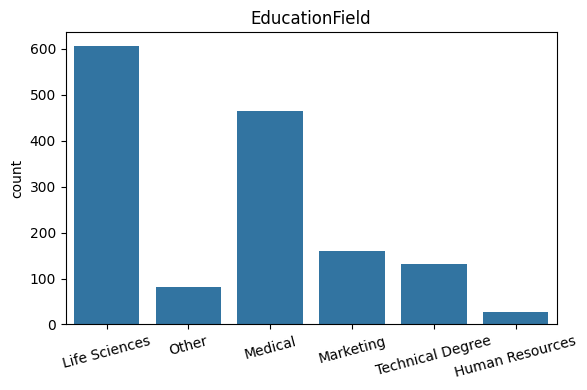

In [14]:
# Distribution of categorical data
for col in df_analysis_copy.select_dtypes(include=["object"]).columns:
  plt.figure(figsize=(6, 4))
  sns.countplot(data=df_analysis_copy, x=col)
  plt.title(col, loc="center")
  plt.xlabel("")
  plt.xticks(rotation=15)
  plt.tight_layout()
  plt.show()
  print("\n" , "\n")

# Analytical Pathway and Evaluation

The Logistic Regression Model will be used to model the relationship between employee attrition and the predictor variables.

In [15]:
# Turn the categorical column EducationField into binaries for analysis
cat_cols = ['EducationField']
ohe = OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore") # dropped the first education field to avoid perfect multicollinearity
ohe_array = ohe.fit_transform(df_analysis[cat_cols])
print("OHE feature names:", ohe.get_feature_names_out(cat_cols))

ohe_df = pd.DataFrame(
    ohe_array, columns=ohe.get_feature_names_out(cat_cols))
df_analysis = pd.concat([df_analysis.reset_index(drop=True), ohe_df], axis=1)
df_analysis = df_analysis.drop(cat_cols, axis="columns")

df_analysis['Attrition'] = df_analysis['Attrition'].map({"Yes":1, "No":0})
df_analysis.head()


OHE feature names: ['EducationField_Life Sciences' 'EducationField_Marketing'
 'EducationField_Medical' 'EducationField_Other'
 'EducationField_Technical Degree']


,Attrition,DistanceFromHome,Education,NumCompaniesWorked,PercentSalaryHike,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree
0,1,1,2,8,11,8,0,1,1.0,0.0,0.0,0.0,0.0
1,0,8,1,1,23,10,3,3,1.0,0.0,0.0,0.0,0.0
2,1,2,2,6,15,7,3,3,0.0,0.0,0.0,1.0,0.0
3,0,3,4,1,11,8,3,3,1.0,0.0,0.0,0.0,0.0
4,0,2,1,9,12,6,3,3,0.0,0.0,1.0,0.0,0.0


In [16]:
# Split the target variable from the features
features = df_analysis.drop('Attrition', axis="columns").copy()
target = df_analysis['Attrition'].copy()

# Create a one constant column for baseline
constant = pd.Series(np.ones(len(df_analysis['Attrition']))).to_frame()
base_target = target.copy()

### Intercept-Only Logistic Model as Baseline

In [17]:
# Split the data into training (75%) and testing (25%) sets
C_train, C_test, b_train, b_test = train_test_split(
    constant, base_target, test_size=0.25, random_state=29
)
# Standardize feature values on a similar scale
scaler = StandardScaler()

C_train = scaler.fit_transform(C_train)
C_test = scaler.transform(C_test)

In [18]:
# Train the Logistic Regression model on the scaled training data
model = LogisticRegression(max_iter=1000)
model.fit(C_train, b_train)

LogisticRegression(max_iter=1000)

In [19]:
# Make predictions on unseen test data
b_pred = model.predict(C_test)
b_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
# Get the accuracy of the baseline model
accuracy = accuracy_score(b_test, b_pred)
print(f"Baseline model accuracy: {round(accuracy,2)}")

# Get the precision of the baseline model
precision = precision_score(b_test, b_pred)
print(f"Baseline model precision: {round(precision,2)}")

# Get the recall value of the baseline model
recall = recall_score(b_test, b_pred)
print(f"Baseline model recall: {round(recall,2)}")

# Get the F1 score of the baseline model
f1 = f1_score(b_test, b_pred)
print(f"Baseline model f1 score: {round(f1,2)}")

Baseline accuracy: 0.84
Baseline model precision: 0.0
Baseline model recall: 0.0
Baseline model f1 score: 0.0


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


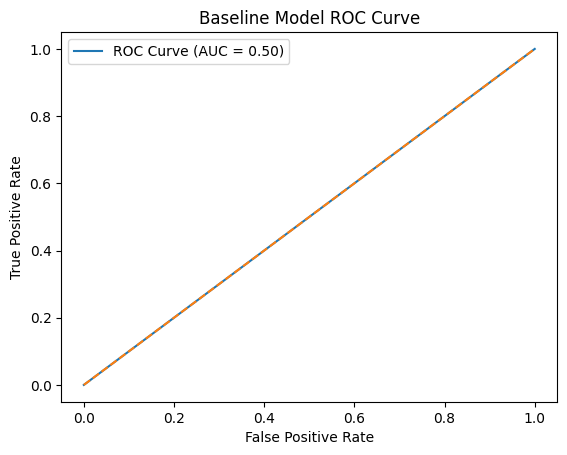

In [21]:
# Get the ROC-AUC Score of the baseline model
b_prob = model.predict_proba(C_test)[:, 1]

fpr, tpr, thresholds = roc_curve(b_test, b_prob)

roc_auc = roc_auc_score(b_test, b_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Baseline Model ROC Curve")
plt.legend()
plt.show()

### Full-Model Logistic Regression Model

In [22]:
# Split the data into training (75%) and testing (25%) sets
F_train, F_test, t_train, t_test = train_test_split(
    features, target, test_size=0.25, random_state=29
)

# Standardize feature values on a similar scale
scaler = StandardScaler()

F_train = scaler.fit_transform(F_train)
F_test = scaler.transform(F_test)

In [23]:
# Train the Logistic Regression model on the scaled training data
model = LogisticRegression(max_iter=1000)
model.fit(F_train, t_train)

LogisticRegression(max_iter=1000)

In [24]:
# Make predictions on unseen test data
t_pred = model.predict(F_test)
t_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [25]:
# Get the accuracy of the full-model
accuracy = accuracy_score(t_test, t_pred)
print(f"Full-model accuracy: {round(accuracy,2)}")

# Get the precision of the full-model
precision = precision_score(t_test, t_pred)
print(f"Full-model precision: {round(precision,2)}")

# Get the recall value of the full-model
recall = recall_score(t_test, t_pred)
print(f"Full-model recall: {round(recall,2)}")

# Get the F1 score of the full-model
f1 = f1_score(t_test, t_pred)
print(f"Full-model f1 score: {round(f1,2)}")

Full-model accuracy: 0.84
Full-model precision: 0.5
Full-model recall: 0.03
Full-model f1 score: 0.06


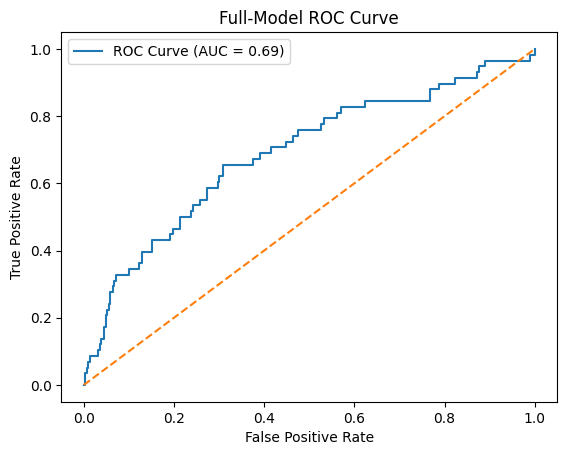

In [26]:
# Get the ROC-AUC Score of the full-model
t_prob = model.predict_proba(F_test)[:, 1]

fpr, tpr, thresholds = roc_curve(t_test, t_prob)

roc_auc = roc_auc_score(t_test, t_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Full-Model ROC Curve")
plt.legend()
plt.show()

### Coefficients of Each Predictor

In [27]:
# Get the Coefficient and Odds Ratio
feature_names = features.columns
coefficients = model.coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df["Odds_Ratio"] = np.exp(
    coef_df["Coefficient"]
)

print(coef_df)

                            Feature  Coefficient  Odds_Ratio
0                  DistanceFromHome     0.227721    1.255735
1                         Education    -0.096819    0.907720
2                NumCompaniesWorked     0.276695    1.318764
3                 PercentSalaryHike    -0.023555    0.976720
4                 TotalWorkingYears    -0.722672    0.485453
5             TrainingTimesLastYear    -0.090881    0.913126
6                   WorkLifeBalance    -0.129092    0.878893
7      EducationField_Life Sciences    -0.430200    0.650379
8          EducationField_Marketing    -0.082804    0.920532
9            EducationField_Medical    -0.452903    0.635780
10             EducationField_Other    -0.233983    0.791376
11  EducationField_Technical Degree    -0.035448    0.965173


In [28]:
# Turn the ndarray to DF
F_train_df = pd.DataFrame(
    F_train,
    columns=feature_names,
    index=t_train.index
)

In [29]:
# Add intercept
F_train_sm = sm.add_constant(
    F_train_df,
    has_constant="add"
)

# Fit logistic regression
logit_model = sm.Logit(
    t_train,
    F_train_sm
)

result = logit_model.fit()

Optimization terminated successfully.
         Current function value: 0.407763
         Iterations 7


In [30]:
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:              Attrition   No. Observations:                 1102
Model:                          Logit   Df Residuals:                     1089
Method:                           MLE   Df Model:                           12
Date:                Fri, 25 Sep 2026   Pseudo R-squ.:                 0.08095
Time:                        10:38:17   Log-Likelihood:                -449.36
converged:                       True   LL-Null:                       -488.94
Covariance Type:            nonrobust   LLR p-value:                 5.963e-12
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                              -1.8501      0.098    -18.916      0.000      -2.042      -1.658
DistanceFromHome                    0.2300      0.082      2.789    